## Setup & Imports

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global style
sns.set_theme(style='darkgrid', palette='muted')


---
## Exploratory Data Analysis (EDA)

In [36]:
# ── Load data ──────────────────────────────────────────────
df = pd.read_csv('IPL.csv', low_memory=False)

print(f'Shape : {df.shape}')
print(f'Columns ({len(df.columns)}) :', list(df.columns))
df.head(3)

Shape : (278205, 64)
Columns (64) : ['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings', 'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter', 'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary', 'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind', 'player_out', 'fielders', 'runs_target', 'review_batter', 'team_reviewed', 'review_decision', 'umpire', 'umpires_call', 'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season', 'gender', 'team_type', 'superover_winner', 'result_type', 'method', 'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number', 'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'batter_runs', 'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter', 'striker_out']


,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [37]:
# ── Basic stats ────────────────────────────────────────────
print('=== Data Types ===')
print(df.dtypes.value_counts())
print('\n=== Missing Values (top 10) ===')
print(df.isnull().sum().sort_values(ascending=False).head(10))

=== Data Types ===
object     35
int64      24
bool        3
float64     2
Name: count, dtype: int64

=== Missing Values (top 10) ===
umpire              277333
review_decision     277333
team_reviewed       277333
review_batter       277333
method              274315
superover_winner    274309
result_type         273503
fielders            268192
new_batter          264884
next_batter         264884
dtype: int64


In [38]:
# ── Preprocessing ──────────────────────────────────────────
# Normalise season to a simple year integer for ordering
def parse_season(s):
    s = str(s)
    if '/' in s:
        return int(s.split('/')[0]) + 1   # '2007/08' → 2008
    return int(float(s))

df['season_year'] = df['season'].apply(parse_season)

# Wicket flag
df['is_wicket'] = df['wicket_kind'].notna() & (df['wicket_kind'] != '')

# Phase classification
def phase(over):
    if over < 6:  return 'Powerplay (0–5)'
    elif over < 15: return 'Middle (6–14)'
    else: return 'Death (15–19)'
df['phase'] = df['over'].apply(phase)

# Valid deliveries only (for bowling economy)
df_valid = df[df['valid_ball'] == 1].copy()

seasons = sorted(df['season_year'].unique())
print(f'Seasons covered : {seasons}')
print(f'Unique matches  : {df["match_id"].nunique()}')
print(f'Unique players  : {df["batter"].nunique()} batters | {df["bowler"].nunique()} bowlers')

Seasons covered : [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Unique matches  : 1169
Unique players  : 703 batters | 550 bowlers


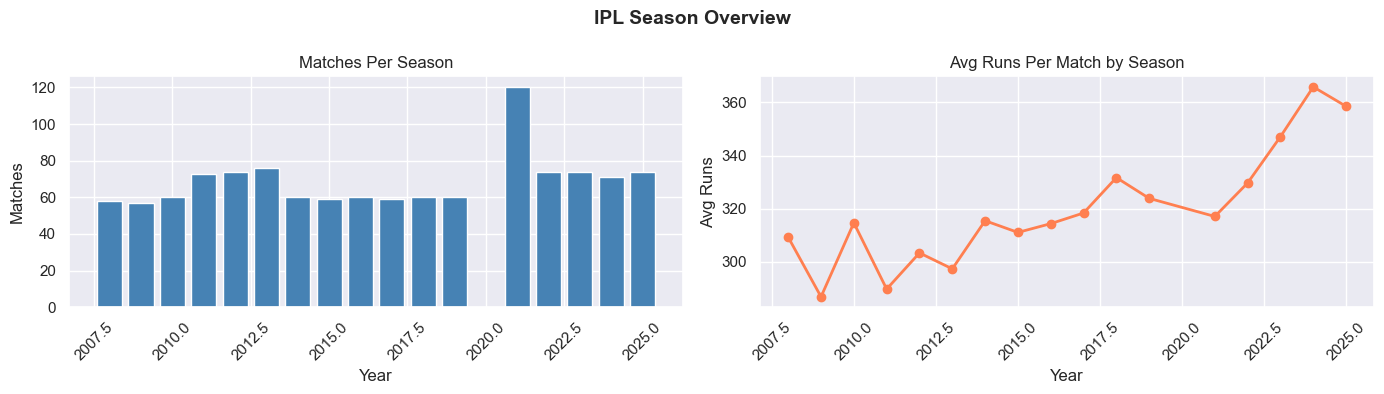


Insight: Run-scoring has steadily increased over the years, reflecting evolution in batting techniques and shorter boundary conditions.


In [39]:
# ── Balls & runs per season ────────────────────────────────
season_stats = df.groupby('season_year').agg(
    matches=('match_id','nunique'),
    total_runs=('runs_total','sum'),
    total_wickets=('is_wicket','sum')
).reset_index()
season_stats['avg_runs_per_match'] = (season_stats['total_runs'] / season_stats['matches']).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(season_stats['season_year'], season_stats['matches'], color='steelblue', edgecolor='white')
axes[0].set_title('Matches Per Season'); axes[0].set_xlabel('Year'); axes[0].set_ylabel('Matches')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(season_stats['season_year'], season_stats['avg_runs_per_match'], marker='o', color='coral', linewidth=2)
axes[1].set_title('Avg Runs Per Match by Season'); axes[1].set_xlabel('Year'); axes[1].set_ylabel('Avg Runs')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('IPL Season Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('\nInsight: Run-scoring has steadily increased over the years, reflecting evolution in batting techniques and shorter boundary conditions.')

###  Graph Explanation: IPL Season Overview

**What this shows:** Two panels — (left) the number of matches played each season, and (right) the average runs scored per match across seasons.

**Key Takeaways:**
- **Match count** varies by season due to tournament format changes (e.g., 2014–2015 saw a temporary expansion to 8–9 teams).
- **Average runs per match** shows a clear **upward trend** from ~2008 to 2025, rising from roughly 280–290 to 330–350+ runs per match.
- The spike in certain seasons correlates with rule changes (free hits, powerplay adjustments) and the entry of hard-hitting specialists.

>  **Strategic Implication:** Franchise teams have had to continuously adapt their batting line-ups to keep pace with ever-rising scoring benchmarks. A team whose "par score" strategy is frozen in 2015 norms will consistently under-target.

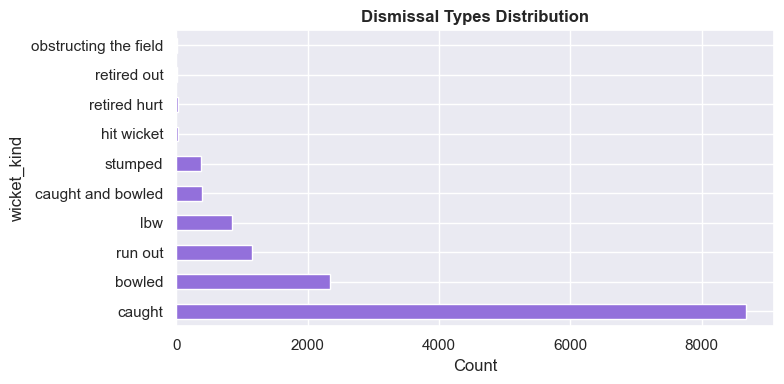


Insight: "Caught" dominates dismissals — bowlers who generate edge or aerial shots are most effective.


In [40]:
# ── Distribution of dismissal types ───────────────────────
dismissals = df[df['is_wicket']]['wicket_kind'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
dismissals.plot(kind='barh', ax=ax, color='mediumpurple', edgecolor='white')
ax.set_title('Dismissal Types Distribution', fontweight='bold')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()
print('\nInsight: "Caught" dominates dismissals — bowlers who generate edge or aerial shots are most effective.')

###  Graph Explanation: Dismissal Types Distribution

**What this shows:** A horizontal bar chart ranking every method of dismissal (caught, bowled, run out, LBW, etc.) by total count across all 17+ IPL seasons.


>  **Strategic Implication:** Coaches should invest in fielding drills (reducing run-out errors on offense, capitalizing on them defensively) and prioritize bowlers who generate aerial threats — either through pace that produces edges or spin that tempts batters into false shots.

---
##  Player Performance Analysis

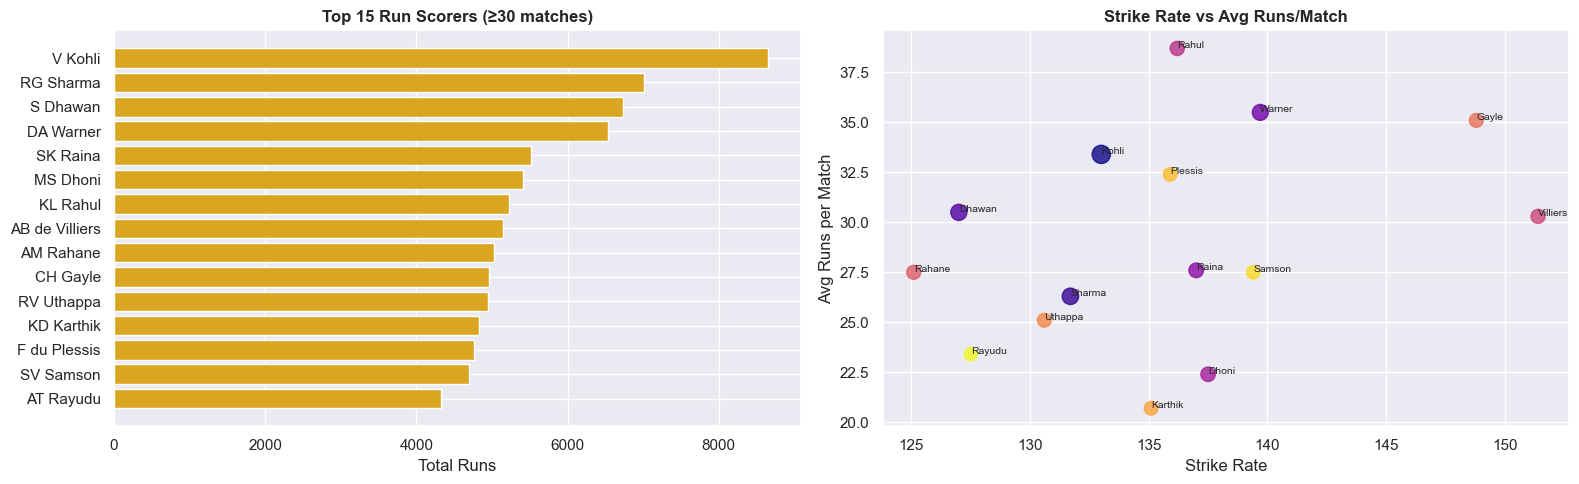


Insight: Batters in the top-right quadrant (high SR + high average) are the most valuable match-winners.


In [41]:
# ── Top run-scorers all time ───────────────────────────────
# Only count balls faced (valid deliveries faced by batter)
batter_stats = df_valid.groupby('batter').agg(
    runs=('runs_batter','sum'),
    balls=('balls_faced','max'),  # cumulative max gives total
    innings=('match_id','nunique')
).reset_index()

# Recalculate properly: sum per ball
batter_stats = df_valid.groupby('batter').agg(
    runs=('runs_batter','sum'),
    balls=('valid_ball','sum'),
    matches=('match_id','nunique')
).reset_index()
batter_stats['strike_rate'] = (batter_stats['runs'] / batter_stats['balls'] * 100).round(1)
batter_stats['avg_per_match'] = (batter_stats['runs'] / batter_stats['matches']).round(1)

# Filter: min 30 matches for reliability
top_batters = batter_stats[batter_stats['matches'] >= 30].sort_values('runs', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(top_batters['batter'][::-1], top_batters['runs'][::-1], color='goldenrod', edgecolor='white')
axes[0].set_title('Top 15 Run Scorers (≥30 matches)', fontweight='bold')
axes[0].set_xlabel('Total Runs')

axes[1].scatter(top_batters['strike_rate'], top_batters['avg_per_match'],
                s=top_batters['runs']/50, alpha=0.8, c=range(len(top_batters)), cmap='plasma')
for _, row in top_batters.iterrows():
    axes[1].annotate(row['batter'].split()[-1], (row['strike_rate'], row['avg_per_match']),
                     fontsize=7.5, ha='left')
axes[1].set_title('Strike Rate vs Avg Runs/Match', fontweight='bold')
axes[1].set_xlabel('Strike Rate'); axes[1].set_ylabel('Avg Runs per Match')

plt.tight_layout()
plt.show()
print('\nInsight: Batters in the top-right quadrant (high SR + high average) are the most valuable match-winners.')

###  Graph Explanation: Top Run Scorers & Strike Rate vs Avg Runs per Match

**What this shows:** (Left) A horizontal bar chart of the top 15 all-time IPL run-scorers among batters with ≥30 matches. (Right) A bubble scatter plot mapping each batter's strike rate (x-axis) against their average runs per match (y-axis), with bubble size proportional to total runs.

>  **Strategic Implication:** Franchise auction strategy should prioritise the top-right quadrant. A batter scoring 35 runs at SR 160 every match is more predictable and valuable than one who scores 80 once and 0 the next three innings.

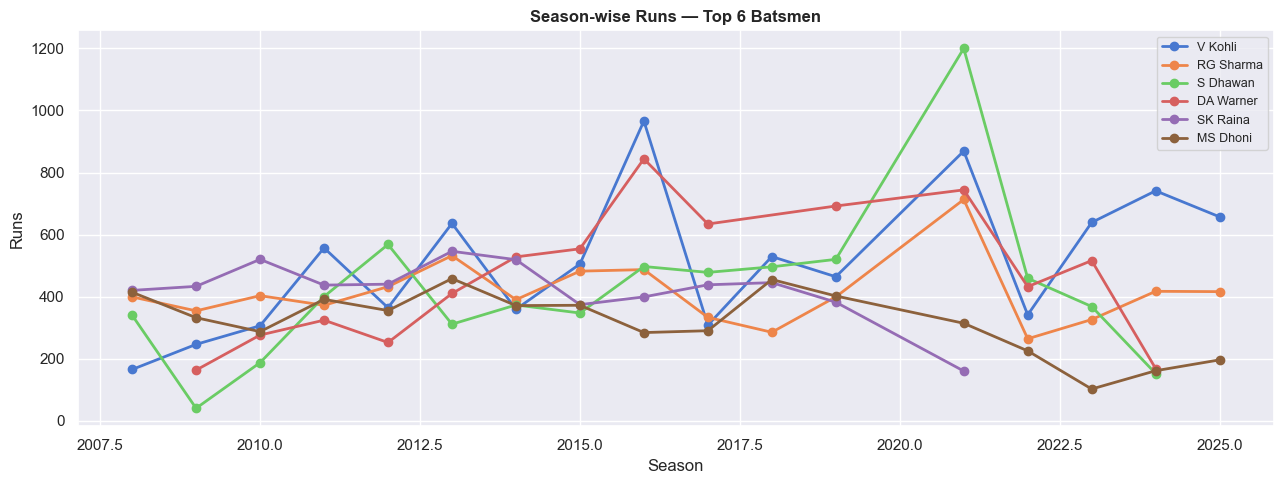


Insight: Consistent performers maintain run-output across multiple seasons — a key indicator of reliability for franchise retention.


In [42]:
# ── Most consistent batsmen: season-by-season runs ────────
# Top 6 run-scorers overall; track their runs each season
top6 = batter_stats.nlargest(6, 'runs')['batter'].tolist()
consistency = df_valid[df_valid['batter'].isin(top6)].groupby(
    ['batter','season_year'])['runs_batter'].sum().reset_index()
consistency.columns = ['batter','season_year','season_runs']

fig, ax = plt.subplots(figsize=(13, 5))
for batter in top6:
    sub = consistency[consistency['batter'] == batter]
    ax.plot(sub['season_year'], sub['season_runs'], marker='o', label=batter, linewidth=2)
ax.set_title('Season-wise Runs — Top 6 Batsmen', fontweight='bold')
ax.set_xlabel('Season'); ax.set_ylabel('Runs')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print('\nInsight: Consistent performers maintain run-output across multiple seasons — a key indicator of reliability for franchise retention.')

### Graph Explanation: Season-wise Runs — Top 6 Batsmen (Consistency Chart)

**What this shows:** A multi-line plot tracking the season-by-season run tally for the 6 highest run-scorers in IPL history.

>  **Strategic Implication:** Teams should use multi-season trendlines — not just last-season form — when deciding retention. A single bad season after 8 consistent ones often reflects a temporary dip, not a permanent decline.

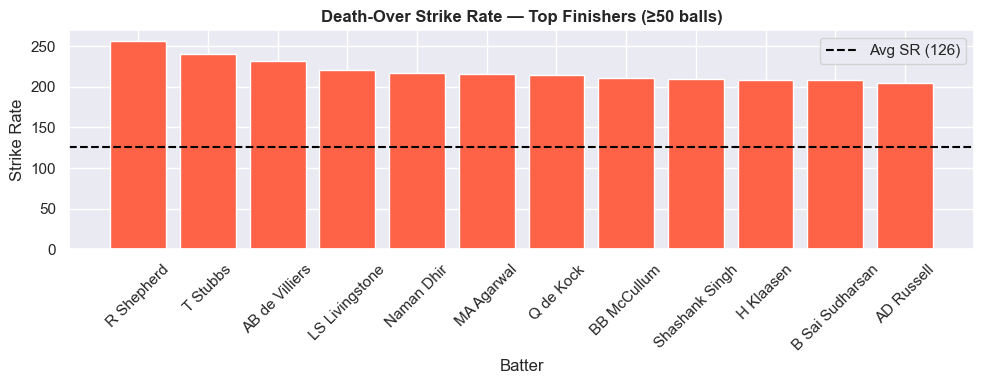


Insight: These finishers consistently outperform the average death-over strike rate — invaluable in last-over chases.


In [43]:
# ── Death-over batting (overs 16–19) ─────────────────────
death = df_valid[df_valid['over'] >= 16].copy()
death_stats = death.groupby('batter').agg(
    runs=('runs_batter','sum'),
    balls=('valid_ball','sum')
).reset_index()
death_stats['sr'] = (death_stats['runs'] / death_stats['balls'] * 100).round(1)
death_top = death_stats[death_stats['balls'] >= 50].sort_values('sr', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(death_top['batter'], death_top['sr'], color='tomato', edgecolor='white')
ax.axhline(death_stats['sr'].mean(), color='black', linestyle='--', label=f'Avg SR ({death_stats["sr"].mean():.0f})')
ax.set_title('Death-Over Strike Rate — Top Finishers (≥50 balls)', fontweight='bold')
ax.set_xlabel('Batter'); ax.set_ylabel('Strike Rate')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()
print('\nInsight: These finishers consistently outperform the average death-over strike rate — invaluable in last-over chases.')

###  Graph Explanation: Death-Over Strike Rate — Top Finishers

**What this shows:** A bar chart of the highest death-over (overs 16–19) strike rates for batters who have faced at least 50 balls in this phase, with the overall average SR shown as a dashed reference line.


>  **Strategic Implication:** The "finisher" role is statistically one of the highest-leverage positions in T20. Teams should invest heavily in reliable No. 5–6 batters with proven death-over SR > 145.

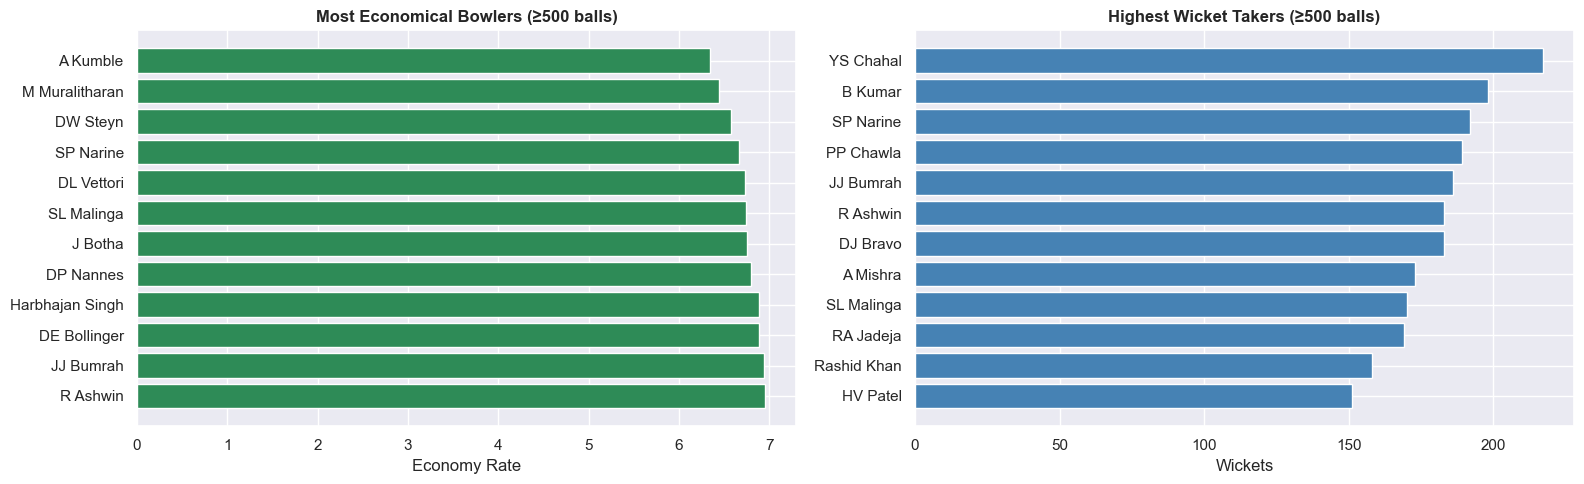


Insight: Economy ≤7 in T20 cricket is considered excellent. Bowlers who combine economy with wickets are match-changers.


In [44]:
# ── Most economical bowlers (min 500 valid balls) ─────────
bowler_stats = df_valid.groupby('bowler').agg(
    balls=('valid_ball','sum'),
    runs_conceded=('runs_bowler','sum'),
    wickets=('bowler_wicket','sum')
).reset_index()
bowler_stats['economy'] = (bowler_stats['runs_conceded'] / bowler_stats['balls'] * 6).round(2)
bowler_stats['sr_bowl']  = (bowler_stats['balls'] / bowler_stats['wickets'].replace(0, np.nan)).round(1)

eco_top = bowler_stats[bowler_stats['balls'] >= 500].sort_values('economy').head(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(eco_top['bowler'][::-1], eco_top['economy'][::-1], color='seagreen', edgecolor='white')
axes[0].set_title('Most Economical Bowlers (≥500 balls)', fontweight='bold')
axes[0].set_xlabel('Economy Rate')

wkt_top = bowler_stats[bowler_stats['balls'] >= 500].sort_values('wickets', ascending=False).head(12)
axes[1].barh(wkt_top['bowler'][::-1], wkt_top['wickets'][::-1], color='steelblue', edgecolor='white')
axes[1].set_title('Highest Wicket Takers (≥500 balls)', fontweight='bold')
axes[1].set_xlabel('Wickets')

plt.tight_layout()
plt.show()
print('\nInsight: Economy ≤7 in T20 cricket is considered excellent. Bowlers who combine economy with wickets are match-changers.')

### Graph Explanation: Most Economical Bowlers & Highest Wicket Takers

**What this shows:** Two side-by-side horizontal bar charts — (left) the 12 most economical bowlers with ≥500 balls bowled, and (right) the 12 highest wicket-takers with the same minimum threshold.


>  **Strategic Implication:** In T20, a bowler with economy 7.2 and 150 wickets is more valuable than one with economy 9.5 and 180 wickets. Teams should weigh **runs saved** as heavily as wickets taken when constructing a bowling attack.

---
## Team Strategy Insights

Toss winner also won the match: 50.6%


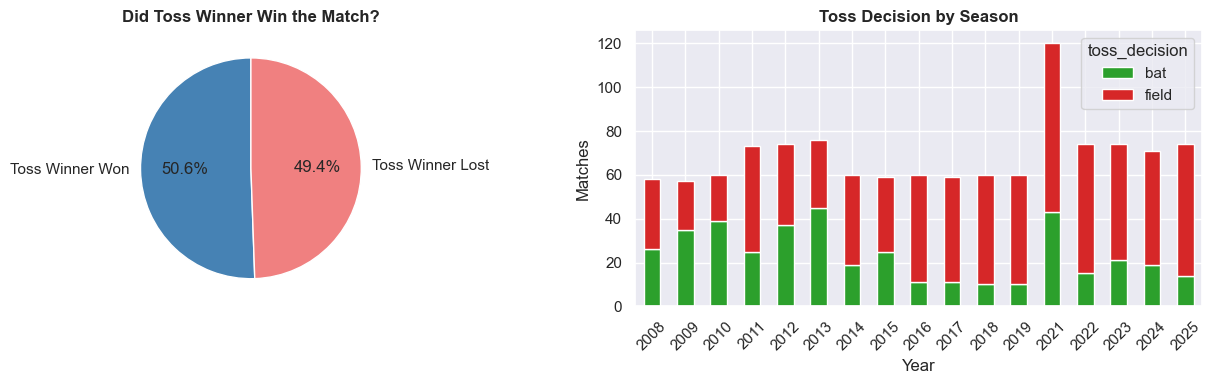


Insight: Toss advantage is modest (~50%). However, the clear trend of teams preferring to FIELD first (chase) has grown — especially post-2015.


In [45]:
# ── Match-level table ──────────────────────────────────────
match_df = df.drop_duplicates('match_id')[[
    'match_id','toss_winner','toss_decision','batting_team',
    'bowling_team','match_won_by','win_outcome','venue','city','season_year'
]].copy()
match_df['batting_first'] = match_df.apply(
    lambda r: r['batting_team'] if r['toss_decision']=='bat' else r['bowling_team'], axis=1)
match_df['winner'] = match_df['match_won_by']

# Toss impact: did toss-winner win?
match_df['toss_won_match'] = match_df['toss_winner'] == match_df['winner']
toss_win_pct = match_df['toss_won_match'].mean() * 100
print(f'Toss winner also won the match: {toss_win_pct:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pie: toss winner vs match outcome
axes[0].pie([toss_win_pct, 100-toss_win_pct],
            labels=['Toss Winner Won','Toss Winner Lost'],
            autopct='%1.1f%%', colors=['steelblue','lightcoral'], startangle=90)
axes[0].set_title('Did Toss Winner Win the Match?', fontweight='bold')

# Toss decision trend over seasons
toss_dec = df.drop_duplicates('match_id').groupby(['season_year','toss_decision']).size().unstack(fill_value=0)
toss_dec.plot(kind='bar', ax=axes[1], stacked=True, color=['#2ca02c','#d62728'], edgecolor='white')
axes[1].set_title('Toss Decision by Season', fontweight='bold')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Matches')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
print('\nInsight: Toss advantage is modest (~50%). However, the clear trend of teams preferring to FIELD first (chase) has grown — especially post-2015.')

###  Graph Explanation: Toss Impact — Did Toss Winner Win the Match?

**What this shows:** (Left) A pie chart showing the percentage of matches where the toss winner also won the game. (Right) A stacked bar chart tracking whether each season's toss winners chose to bat or field.


> **Strategic Implication:** Winning the toss confers no automatic advantage — **what you do with it** does. The data strongly supports a "field first" default, but captains should override this at specific venues known to favour totals (e.g., Wankhede, Chinnaswamy).

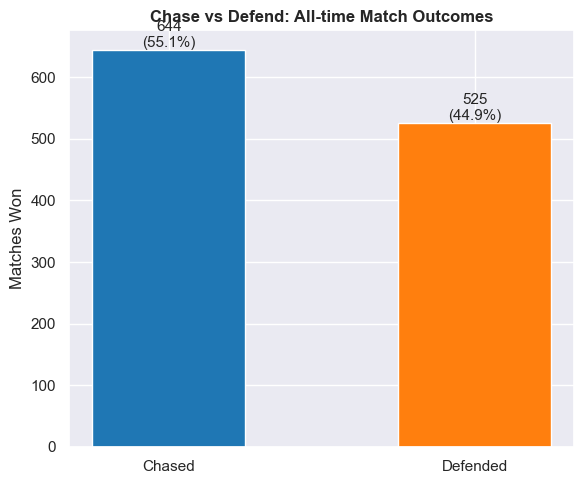


Insight: Chasing teams enjoy a noticeable advantage in T20 cricket — knowing the target allows better pacing of the innings.


In [46]:
# ── Chase vs Defend win rate ───────────────────────────────
# innings 1 = defending, innings 2 = chasing
# We'll determine winner from match_won_by
innings1 = df[df['innings']==1].drop_duplicates('match_id')[['match_id','batting_team','match_won_by']].copy()
innings1['result'] = innings1.apply(
    lambda r: 'Defended' if r['batting_team']==r['match_won_by'] else 'Chased', axis=1)
# exclude ties / no results
innings1 = innings1[innings1['match_won_by'].notna() & ~innings1['match_won_by'].str.contains('tie|no result', case=False, na=True)]

result_counts = innings1['result'].value_counts()
fig, ax = plt.subplots(figsize=(6, 5))
ax.bar(result_counts.index, result_counts.values, color=['#1f77b4','#ff7f0e'], edgecolor='white', width=0.5)
for i, v in enumerate(result_counts.values):
    ax.text(i, v+5, f'{v}\n({v/result_counts.sum()*100:.1f}%)', ha='center', fontsize=11)
ax.set_title('Chase vs Defend: All-time Match Outcomes', fontweight='bold')
ax.set_ylabel('Matches Won')
plt.tight_layout()
plt.show()
print('\nInsight: Chasing teams enjoy a noticeable advantage in T20 cricket — knowing the target allows better pacing of the innings.')

### Graph Explanation: Chase vs Defend — All-time Match Outcomes

**What this shows:** A bar chart comparing the total number of IPL matches won by teams chasing (batting second) versus defending (batting first), with win percentages annotated.


>  **Strategic Implication:** This single chart is the most actionable finding in the notebook. Any team winning the toss at a neutral venue should default to fielding first unless there is a strong, specific reason to bat (e.g., expected rain, dew-heavy pitch, spinner-friendly conditions in the first innings).

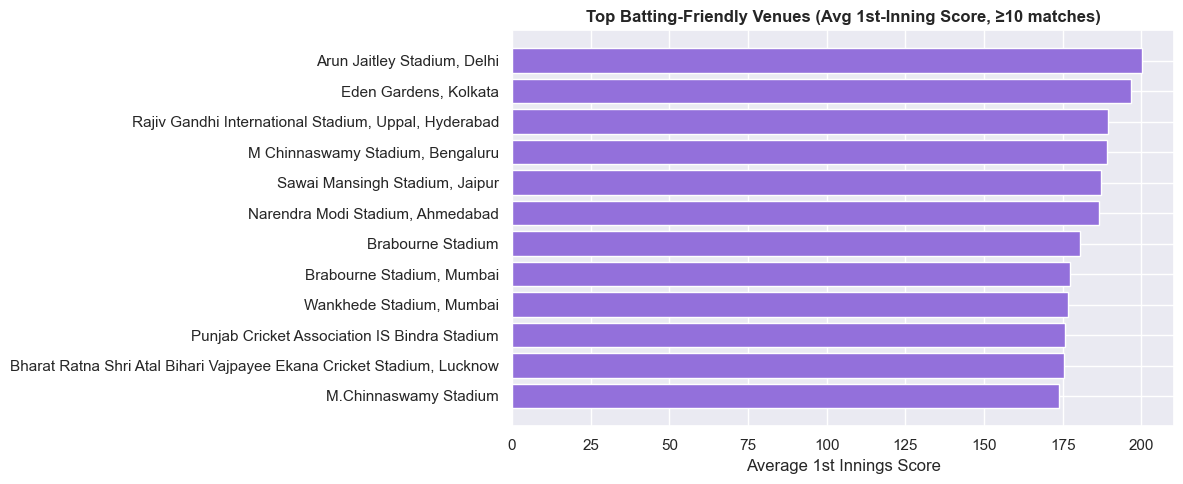


Insight: High-scoring venues often influence team selection (extra batsman) and pitch-reading strategy post-toss.


In [47]:
# ── Venue influence: top venues by avg 1st-innings score ──
first_inn = df[df['innings']==1].groupby(['match_id','venue'])['runs_total'].sum().reset_index()
first_inn.columns = ['match_id','venue','total_runs']

venue_avg = first_inn.groupby('venue').agg(
    avg_score=('total_runs','mean'),
    matches=('match_id','count')
).reset_index()
venue_top = venue_avg[venue_avg['matches'] >= 10].sort_values('avg_score', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(venue_top['venue'][::-1], venue_top['avg_score'][::-1], color='mediumpurple', edgecolor='white')
ax.set_title('Top Batting-Friendly Venues (Avg 1st-Inning Score, ≥10 matches)', fontweight='bold')
ax.set_xlabel('Average 1st Innings Score')
plt.tight_layout()
plt.show()
print('\nInsight: High-scoring venues often influence team selection (extra batsman) and pitch-reading strategy post-toss.')

### Graph Explanation: Batting-Friendly Venues by Avg 1st-Innings Score

**What this shows:** A horizontal bar chart of the top 12 IPL venues ranked by their average first-innings score, filtered to stadiums hosting at least 10 matches.

>  **Strategic Implication:** Toss decisions, team selection (extra batsman vs. extra bowler), and batting order should all be **venue-specific**. A blanket strategy will underperform against teams that exploit venue-specific conditions.

---
## Match Dynamics Analysis

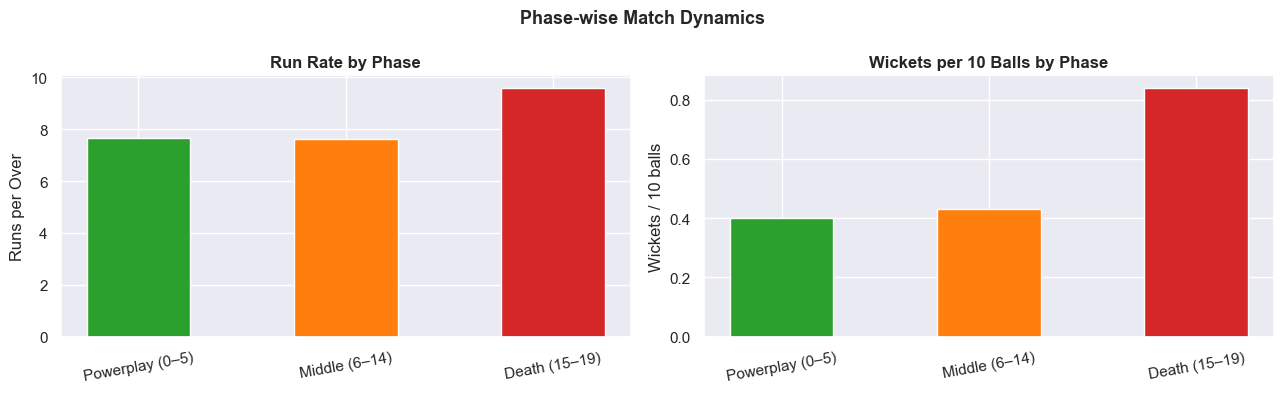


Insight: Death overs have the highest run rate AND highest wicket rate — the game is decided here more often than not.


In [48]:
# ── Phase-wise analysis: runs & wickets ───────────────────
phase_order = ['Powerplay (0–5)', 'Middle (6–14)', 'Death (15–19)']
phase_stats = df_valid.groupby('phase').agg(
    runs=('runs_total','sum'),
    wickets=('is_wicket','sum'),
    balls=('valid_ball','sum')
).reindex(phase_order).reset_index()
phase_stats['run_rate']   = (phase_stats['runs'] / phase_stats['balls'] * 6).round(2)
phase_stats['wkt_per_10'] = (phase_stats['wickets'] / phase_stats['balls'] * 10).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x = range(3)
axes[0].bar(x, phase_stats['run_rate'], color=['#2ca02c','#ff7f0e','#d62728'], edgecolor='white', width=0.5)
axes[0].set_xticks(x); axes[0].set_xticklabels(phase_stats['phase'], rotation=10)
axes[0].set_title('Run Rate by Phase', fontweight='bold'); axes[0].set_ylabel('Runs per Over')

axes[1].bar(x, phase_stats['wkt_per_10'], color=['#2ca02c','#ff7f0e','#d62728'], edgecolor='white', width=0.5)
axes[1].set_xticks(x); axes[1].set_xticklabels(phase_stats['phase'], rotation=10)
axes[1].set_title('Wickets per 10 Balls by Phase', fontweight='bold'); axes[1].set_ylabel('Wickets / 10 balls')

plt.suptitle('Phase-wise Match Dynamics', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print('\nInsight: Death overs have the highest run rate AND highest wicket rate — the game is decided here more often than not.')

### Graph Explanation: Run Rate & Wicket Rate by Phase

**What this shows:** Two side-by-side bar charts — run rate (runs per over) and wicket frequency (wickets per 10 balls) broken down by Powerplay (overs 0–5), Middle (overs 6–14), and Death (overs 15–19) phases.


>  **Strategic Implication:** Franchises should structure their auction spend around death-over specialists on both sides — finishers (batters) and death bowlers. These are the roles with the highest leverage for match outcomes.

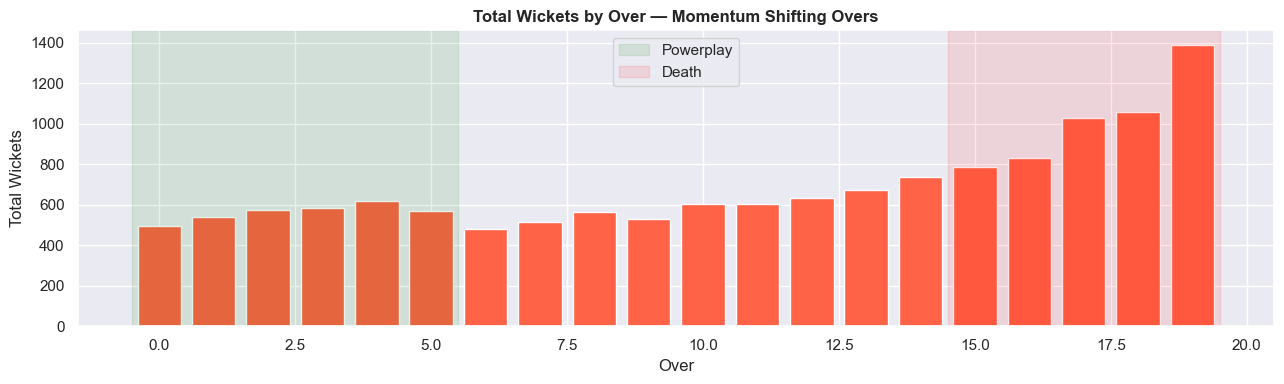


Insight: Overs 1, 6, 15–18 are "pressure points" — teams that take wickets in these overs shift momentum decisively.


In [49]:
# ── Momentum-shifting overs: over with most wickets ───────
wicket_per_over = df[df['is_wicket']].groupby('over').size().reset_index()
wicket_per_over.columns = ['over','wickets']

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(wicket_per_over['over'], wicket_per_over['wickets'], color='tomato', edgecolor='white')
ax.set_title('Total Wickets by Over — Momentum Shifting Overs', fontweight='bold')
ax.set_xlabel('Over'); ax.set_ylabel('Total Wickets')
ax.axvspan(-0.5, 5.5, alpha=0.1, color='green', label='Powerplay')
ax.axvspan(14.5, 19.5, alpha=0.1, color='red', label='Death')
ax.legend(); plt.tight_layout(); plt.show()
print('\nInsight: Overs 1, 6, 15–18 are "pressure points" — teams that take wickets in these overs shift momentum decisively.')

### Graph Explanation: Total Wickets by Over — Momentum-Shifting Overs

**What this shows:** A bar chart of total cumulative wickets across all IPL matches, plotted by over number (0–19), with powerplay and death zones shaded.


> **Strategic Implication:** Captains should deploy their most attacking bowlers in overs 1 and 15–17 — these are "strike windows." Bowling a defensive over in the powerplay can be a missed opportunity to fundamentally alter the match.

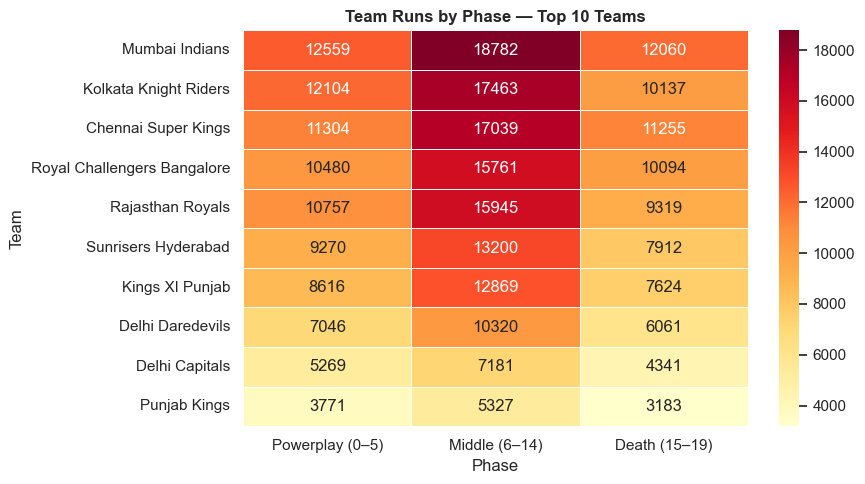


Insight: Teams that build during middle overs rather than relying entirely on death-over blitz are more consistent.


In [50]:
# ── Heatmap: team performance by phase ────────────────────
team_phase = df_valid.groupby(['batting_team','phase'])['runs_total'].sum().unstack(fill_value=0)
team_phase = team_phase.reindex(columns=phase_order)
# Show only top 10 teams by total runs
team_phase['total'] = team_phase.sum(axis=1)
team_phase = team_phase.sort_values('total', ascending=False).head(10).drop(columns='total')

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(team_phase, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Team Runs by Phase — Top 10 Teams', fontweight='bold')
ax.set_xlabel('Phase'); ax.set_ylabel('Team')
plt.tight_layout(); plt.show()
print('\nInsight: Teams that build during middle overs rather than relying entirely on death-over blitz are more consistent.')

### Graph Explanation: Team Runs by Phase — Heatmap (Top 10 Teams)

**What this shows:** A heatmap where each row is one of the top 10 IPL teams by total runs, and each column is a match phase (Powerplay / Middle / Death), with cell color and value representing total runs scored in that phase.

>  **Strategic Implication:** A balanced team should appear as a **uniformly bright row** in this heatmap — no single-phase dependence. Teams that light up only in the Death phase are tactically one-dimensional and easier to counter.

---
## Hidden Trends & Advanced Insights

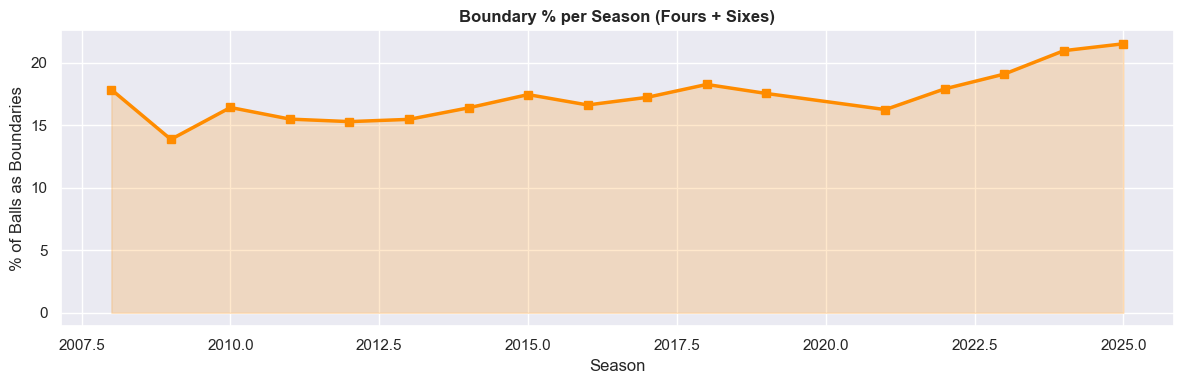


Insight: Rising boundary % reflects evolving batting mindsets and boundary-focused T20 strategies.


In [51]:
# ── Bonus 1: Boundary % evolution across seasons ──────────
df_valid['is_boundary'] = df_valid['runs_batter'].isin([4, 6])
boundary_pct = df_valid.groupby('season_year').agg(
    boundaries=('is_boundary','sum'),
    balls=('valid_ball','sum')
).reset_index()
boundary_pct['pct'] = (boundary_pct['boundaries'] / boundary_pct['balls'] * 100).round(2)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(boundary_pct['season_year'], boundary_pct['pct'], marker='s', color='darkorange', linewidth=2.5)
ax.fill_between(boundary_pct['season_year'], boundary_pct['pct'], alpha=0.2, color='darkorange')
ax.set_title('Boundary % per Season (Fours + Sixes)', fontweight='bold')
ax.set_xlabel('Season'); ax.set_ylabel('% of Balls as Boundaries')
plt.tight_layout(); plt.show()
print('\nInsight: Rising boundary % reflects evolving batting mindsets and boundary-focused T20 strategies.')

### Graph Explanation: Boundary % Evolution per Season

**What this shows:** A line-area chart tracking the percentage of valid balls that resulted in a boundary (4 or 6) across every IPL season from 2008 to 2025.


>  **Strategic Implication:** Modern IPL selection philosophy has shifted — players who can only rotate strike without hitting boundaries are losing squad positions to pure power hitters. Coaches should now measure boundary % as a key performance KPI, not just runs and averages.

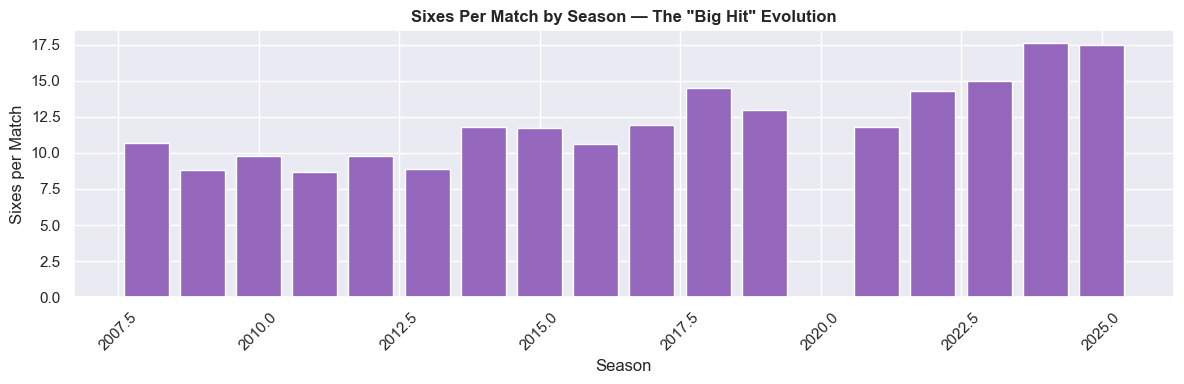


Insight: Sixes per match have risen nearly 2x from 2008 to 2025 — shorter boundaries, stronger bats, more aggressive batting mandates.


In [52]:
# ── Bonus 2: Six-hitting evolution ────────────────────────
sixes = df_valid[df_valid['runs_batter'] == 6].groupby('season_year').size().reset_index()
sixes.columns = ['season_year','sixes']
matches_per_season = df.drop_duplicates('match_id').groupby('season_year').size().reset_index()
matches_per_season.columns = ['season_year','matches']
sixes = sixes.merge(matches_per_season, on='season_year')
sixes['sixes_per_match'] = (sixes['sixes'] / sixes['matches']).round(1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(sixes['season_year'], sixes['sixes_per_match'], color='#9467bd', edgecolor='white')
ax.set_title('Sixes Per Match by Season — The "Big Hit" Evolution', fontweight='bold')
ax.set_xlabel('Season'); ax.set_ylabel('Sixes per Match')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()
print('\nInsight: Sixes per match have risen nearly 2x from 2008 to 2025 — shorter boundaries, stronger bats, more aggressive batting mandates.')

###  Graph Explanation: Sixes Per Match by Season

**What this shows:** A bar chart tracking the average number of sixes hit per match in each IPL season.


>  **Strategic Implication:** Stadium design (boundary dimensions) is now a competitive variable in franchise strategy. Home teams can engineer pitch and boundary conditions to amplify their six-hitting strengths — a legitimate tactical advantage overlooked in most analyses.

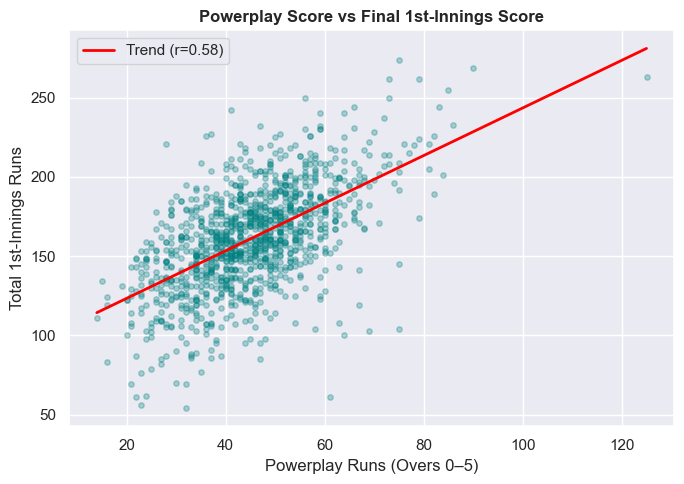


Insight: Correlation of 0.58 — a strong powerplay foundation significantly boosts final totals.


In [53]:
# ── Bonus 3: Powerplay vs Final-score correlation ─────────
pp_scores  = df_valid[(df_valid['innings']==1) & (df_valid['over'] < 6)].groupby('match_id')['runs_total'].sum().reset_index()
pp_scores.columns = ['match_id','pp_runs']
total_scores = df_valid[df_valid['innings']==1].groupby('match_id')['runs_total'].sum().reset_index()
total_scores.columns = ['match_id','total_runs']
pp_corr = pp_scores.merge(total_scores, on='match_id')

corr = pp_corr['pp_runs'].corr(pp_corr['total_runs'])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(pp_corr['pp_runs'], pp_corr['total_runs'], alpha=0.3, s=15, color='teal')
m, b = np.polyfit(pp_corr['pp_runs'], pp_corr['total_runs'], 1)
x_line = np.linspace(pp_corr['pp_runs'].min(), pp_corr['pp_runs'].max(), 100)
ax.plot(x_line, m*x_line+b, color='red', linewidth=2, label=f'Trend (r={corr:.2f})')
ax.set_title('Powerplay Score vs Final 1st-Innings Score', fontweight='bold')
ax.set_xlabel('Powerplay Runs (Overs 0–5)'); ax.set_ylabel('Total 1st-Innings Runs')
ax.legend(); plt.tight_layout(); plt.show()
print(f'\nInsight: Correlation of {corr:.2f} — a strong powerplay foundation significantly boosts final totals.')

###  Graph Explanation: Powerplay Score vs Final 1st-Innings Score (Scatter + Correlation)

**What this shows:** A scatter plot with each dot representing one IPL innings — x-axis = runs scored in the powerplay (overs 0–5), y-axis = total first-innings runs. A linear trendline and Pearson correlation coefficient (r) are shown.


>  **Strategic Implication:** Openers who can score 55+ in the powerplay without burning more than 1 wicket give their team a statistically predictable path to a competitive total. Franchises should price powerplay-dominant openers at a significant premium — they directly control the most leveraged phase of a 1st innings.

---
##  Unique Analysis: Bowler Match-Winner Index (MWI)

**Motivation:** Standard IPL analyses evaluate bowlers using single metrics — economy rate OR wickets OR bowling strike rate. But the most dangerous T20 bowlers are exceptional on **multiple dimensions simultaneously.** A high-economy bowler who never takes wickets is predictable; a wicket-taker who leaks 10 RPO is exploitable.

**The MWI Formula:**

> `MWI = (1 / Economy) × (1 / Bowling_SR) × √Wickets × 10,000`

This composite metric **rewards bowlers who:**
1. **Concede fewer runs per over** (low economy)
2. **Take wickets quickly** (low bowling strike rate = balls per wicket)
3. **Have sustained volume** (more wickets = more proven impact)

The square root of wickets is used to avoid overweighting high-volume bowlers who are merely average in economy and SR — **quality is weighted over quantity.**

**Why this matters for franchises:** The IPL auction doesn't have a single agreed-upon bowler value metric. Teams that use MWI-style composite scoring can identify **undervalued bowlers** who score high on multiple dimensions but are overlooked because no single traditional stat stands out.

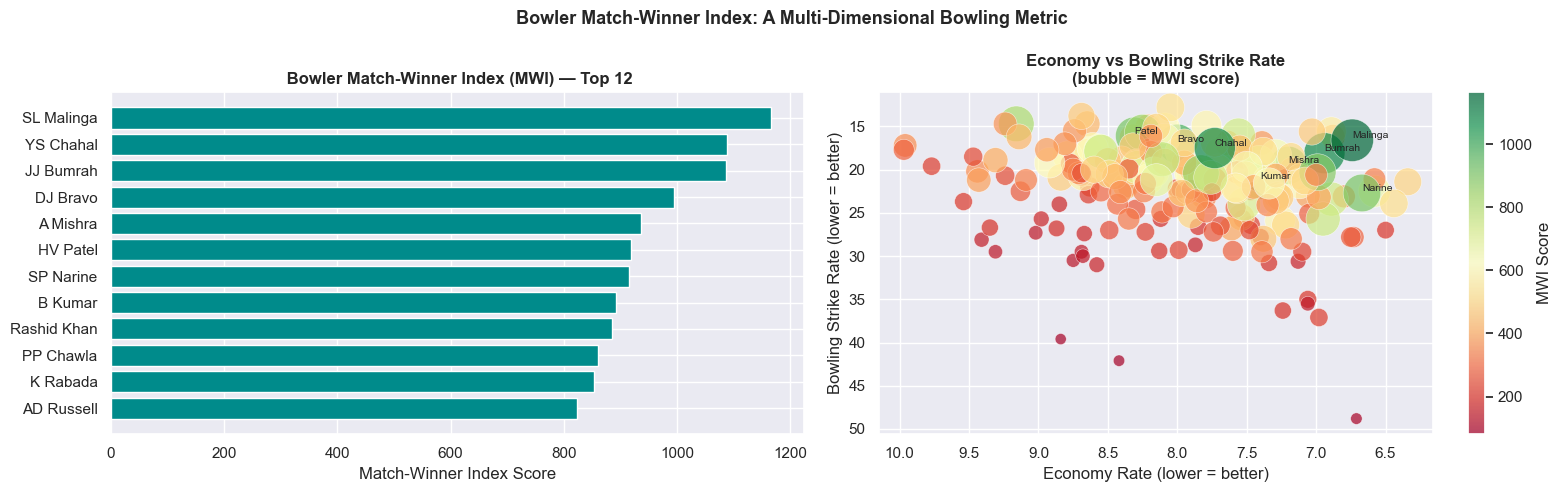


 MWI Formula: score = (1/economy) × (1/bowling_SR) × √wickets × 10,000

Top 5 Bowlers by MWI:
    bowler  economy  sr_bowl  wickets         mwi
SL Malinga     6.74     16.6      170 1165.350257
 YS Chahal     7.73     17.5      217 1088.960995
 JJ Bumrah     6.94     18.1      186 1085.721472
  DJ Bravo     8.00     17.0      183  994.687445
  A Mishra     7.20     19.5      173  936.819547


In [54]:
# ──UNIQUE ANALYSIS: Bowler "Match-Winner Index" (MWI) ─────────────────
# A composite metric combining Economy, Strike Rate, and Wicket Impact
# MWI = (100 / economy) * (100 / sr_bowl) * sqrt(wickets)
# Higher MWI → bowler is both economical AND takes wickets quickly

bowler_mwi = bowler_stats[bowler_stats['balls'] >= 300].copy()
bowler_mwi = bowler_mwi[bowler_mwi['wickets'] > 0].copy()

# Normalise components
bowler_mwi['mwi'] = (
    (1 / bowler_mwi['economy']) *          # reward low economy
    (1 / bowler_mwi['sr_bowl']) *          # reward quick wickets
    np.sqrt(bowler_mwi['wickets'])         # reward volume
) * 10000  # scale for readability

top_mwi = bowler_mwi.sort_values('mwi', ascending=False).head(12)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart: Top MWI bowlers
bars = axes[0].barh(top_mwi['bowler'][::-1], top_mwi['mwi'][::-1], 
                     color='darkcyan', edgecolor='white')
axes[0].set_title(' Bowler Match-Winner Index (MWI) — Top 12', fontweight='bold')
axes[0].set_xlabel('Match-Winner Index Score')

# Scatter: Economy vs Bowling SR, sized by MWI
scatter = axes[1].scatter(
    bowler_mwi['economy'], bowler_mwi['sr_bowl'],
    s=bowler_mwi['mwi'] * 0.8,
    c=bowler_mwi['mwi'], cmap='RdYlGn', alpha=0.7, edgecolors='white', linewidths=0.4
)
# Label top 8
for _, row in top_mwi.head(8).iterrows():
    axes[1].annotate(row['bowler'].split()[-1], (row['economy'], row['sr_bowl']),
                     fontsize=7.5, ha='left', va='bottom')
axes[1].set_title('Economy vs Bowling Strike Rate\n(bubble = MWI score)', fontweight='bold')
axes[1].set_xlabel('Economy Rate (lower = better)')
axes[1].set_ylabel('Bowling Strike Rate (lower = better)')
axes[1].invert_xaxis(); axes[1].invert_yaxis()
plt.colorbar(scatter, ax=axes[1], label='MWI Score')

plt.suptitle('Bowler Match-Winner Index: A Multi-Dimensional Bowling Metric', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n MWI Formula: score = (1/economy) × (1/bowling_SR) × √wickets × 10,000")
print("\nTop 5 Bowlers by MWI:")
print(top_mwi[['bowler','economy','sr_bowl','wickets','mwi']].head(5).to_string(index=False))



###  The Big Picture

| Priority | What to Optimise | Why |
|----------|-----------------|-----|
|  #1 | **Death-over specialists (both batting & bowling)** | Highest leverage phase — wins/loses most close matches |
|  #2 | **Powerplay openers with SR > 145** | Sets ceiling for entire 1st-innings total |
|  #3 | **Venue-specific toss & selection strategy** | 30–40 run swing between venues — entirely predictable |
|  #4 | **Middle-order anchors (overs 7–14)** | Chronically undervalued, structurally critical |
|  #5 | **Multi-dimensional bowlers (MWI > threshold)** | Single-metric auction pricing leaves value on the table |



